# Understanding White Noise

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

## Plot settings

In [2]:
rcParams.update(
    {
        "font.size": 18,
        "axes.titlesize": 25,

        # Figure Settings
        "figure.figsize": (16, 8),
        "figure.facecolor": "white",
        "figure.autolayout": True,  # Equivelant to layout="tight"

        # Show/hide spines
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.bottom": False,
        "axes.spines.left": True,

        # Ticks
        "xtick.bottom": True,  # Hide X ticks
        "xtick.major.size": 5,  # Make Y ticks longer
        "ytick.major.size": 5,  # Make Y ticks longer

        # Update Axes bgcolor
        "axes.facecolor": "whitesmoke",

        # Grid settings
        "axes.grid": True,
        "grid.color": "white",
        "grid.linewidth": 1.5,
        "axes.axisbelow": True,
        "axes.grid.axis": "y",
    }
)

my_blue = "mediumblue"

## Uniform white noise

### Generate

In [3]:
N = 800
np.random.seed(18)
white_uniform = np.random.uniform(
    low=-1,
    high=1,
    size=N
)

In [4]:
white_uniform

array([ 3.00748483e-01,  1.09067475e-02,  7.57202942e-01, -6.36319549e-01,
        7.04466137e-01,  5.00272572e-01,  3.32203335e-01,  9.75790897e-01,
       -4.86063155e-01, -9.43388149e-01,  2.71438231e-01,  6.94624775e-01,
        4.72349250e-01, -9.58385776e-01, -7.76793739e-01, -4.04552516e-01,
        3.73940383e-01,  7.23252112e-01, -6.02731282e-01,  3.14378061e-01,
        3.99311258e-01, -2.95215062e-01,  5.79921096e-01,  6.28095876e-01,
       -6.05157431e-01,  8.98910588e-01, -4.67992280e-02,  3.33200696e-01,
       -5.77375925e-01,  6.15052648e-01, -3.60627759e-01, -4.12128051e-01,
       -3.96163645e-01,  6.55778804e-01,  1.05067378e-01, -6.16645190e-01,
        4.28513481e-01,  2.79740714e-01,  6.64076627e-02,  1.45055827e-01,
       -9.75334925e-01,  3.90475957e-01,  6.93184207e-02, -8.41730565e-01,
       -9.72724997e-01, -4.44293920e-01,  9.94770565e-01, -5.48798724e-01,
       -7.89969294e-01, -9.67398443e-01, -3.16745095e-01,  6.16396117e-01,
       -5.65360754e-01,  

### Visualize

[Text(0.0, 0, '0%'), Text(0.1, 0, '10%')]

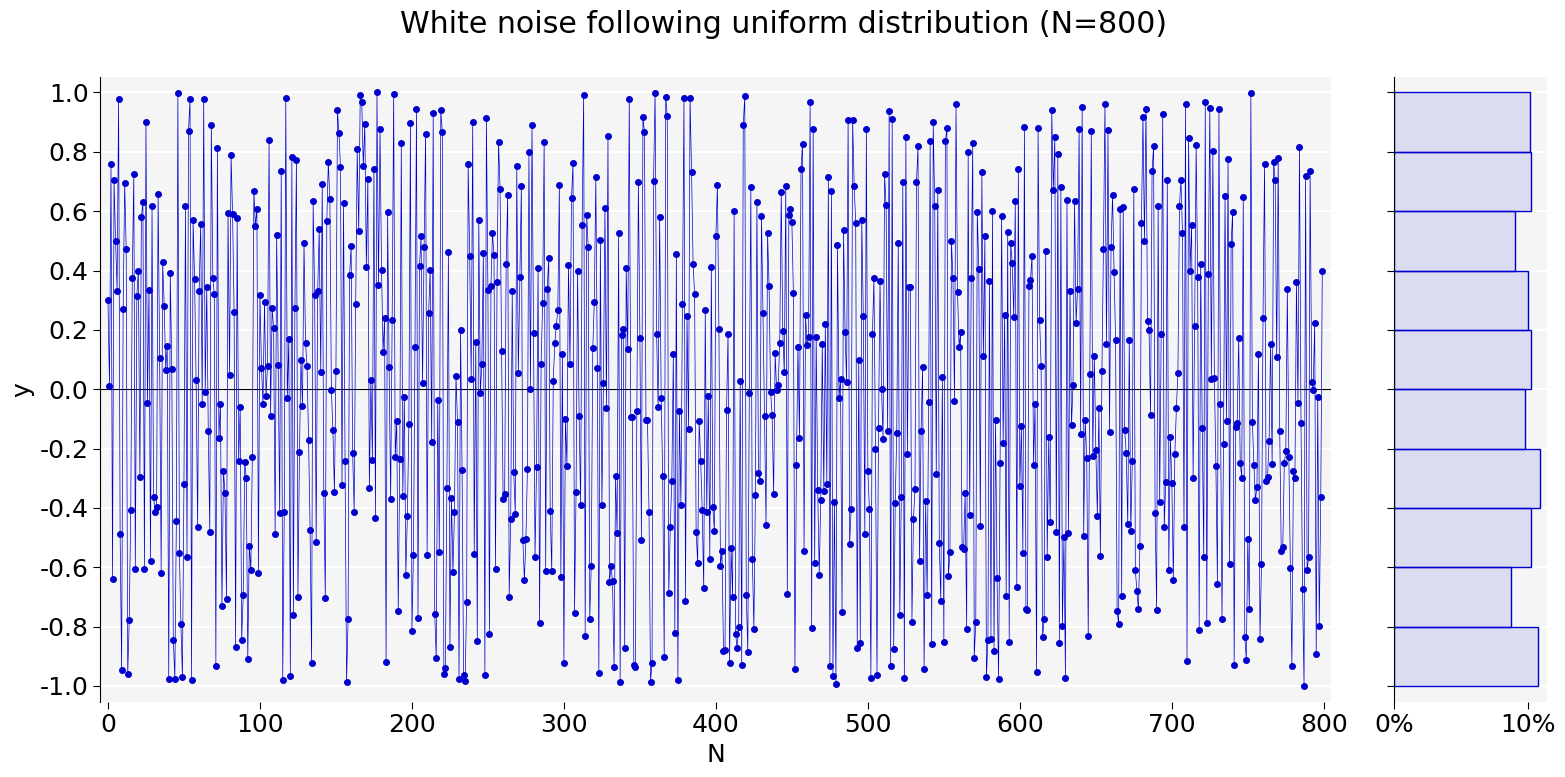

In [5]:
mosaic="aaaaaab"

fig, axs = plt.subplot_mosaic(
    mosaic=mosaic,
    sharey=True,
)

fig.suptitle(f"White noise following uniform distribution (N={N})")

axs["a"].plot(
    white_uniform,
    color=my_blue,
    marker=".",
    markersize=8,
    linewidth=0.5,
)

axs["a"].axhline(
    0,
    color="black",
    linewidth=0.8,
    zorder=1
)

axs["a"].set_xlim(-5, N+5)
axs["a"].set_ylim(-1.05, 1.05)
axs["a"].set_xlabel("N")
axs["a"].set_ylabel("y")


n, bins, patches = axs["b"].hist(
    x=white_uniform,
    color=(my_blue, 0.1),
    edgecolor=my_blue,
    orientation="horizontal",
    histtype="bar",
    weights=np.ones_like(white_uniform) / len(white_uniform)
)

axs["b"].set_yticks(bins)
axs["b"].set_yticklabels([f"{value:.1f}" for value in bins]);
axs["b"].set_xticks([0, 0.1])
axs["b"].set_xticklabels([f"{value:.0%}" for value in [0, 0.1]])

### Check assumptions

#### Mean = 0

In [6]:
signal_mean = np.mean(white_uniform)

print(f"{signal_mean:.3}")

-0.00161


In [7]:
# Standard error of the mean
signal_sem = np.std(white_uniform, ddof=1) / np.sqrt(N)

print(f"{signal_sem:.3}")

0.0205


In [8]:
Z_SCORE = 1.96 # for 95% confidence interval for the mean

ci_mean_low = signal_mean - Z_SCORE * signal_sem
ci_mean_high = signal_mean + Z_SCORE * signal_sem

In [9]:
print(f"CI range (for the mean): [{ci_mean_low:.3f}, {ci_mean_high:.3f}]")

CI range (for the mean): [-0.042, 0.039]


#### Constant variance with known underlying distribution

In [10]:
# Theoretical uniform variance
a = -1
b = 1

uni_theoretical_var = (b - a)**2 / 12
print(f"{uni_theoretical_var:.3f}")

0.333


In [11]:
# Whole signal variance
signal_var_all = np.var(white_uniform, ddof=1)
print(f"{signal_var_all:.3f}")

0.336


In [12]:
# Bootstrapping: resample whole signal with replacement 1000 times
nr_of_bootstrap_runs = 1000

bootstrap_variances = [
    np.var(np.random.choice(white_uniform, size=N, replace=True), ddof=1)
    for _ in range(nr_of_bootstrap_runs)
]

bootstrap_variances

[np.float64(0.360849874203297),
 np.float64(0.3325287192142009),
 np.float64(0.32588147250848654),
 np.float64(0.3580361321424352),
 np.float64(0.33715807121643415),
 np.float64(0.33607050877687783),
 np.float64(0.3172595596159669),
 np.float64(0.3455868583000872),
 np.float64(0.3469496956034419),
 np.float64(0.32857866799176144),
 np.float64(0.33694215651432735),
 np.float64(0.3218426115827387),
 np.float64(0.32339200950620933),
 np.float64(0.34351420253043335),
 np.float64(0.34248618671362674),
 np.float64(0.3553286172913463),
 np.float64(0.3242846942763827),
 np.float64(0.35021453000595715),
 np.float64(0.35400166981124565),
 np.float64(0.32273961718304356),
 np.float64(0.3312982944395062),
 np.float64(0.32626038447791333),
 np.float64(0.3252030838432989),
 np.float64(0.33887160606296174),
 np.float64(0.32022803073812955),
 np.float64(0.3238997232453604),
 np.float64(0.34159199295251336),
 np.float64(0.31325041266645504),
 np.float64(0.33677450439505663),
 np.float64(0.3397920956098

In [13]:
print(f"Min: {np.min(bootstrap_variances):.3f}  -  Max: {np.max(bootstrap_variances):.3f}")

Min: 0.305  -  Max: 0.371


In [14]:
# Calculate bootstrapped confidence intervals using percentile method
alpha = 0.05
ci_var_low = np.percentile(bootstrap_variances, 100 * alpha / 2)
ci_var_high = np.percentile(bootstrap_variances, 100 * (1 - alpha / 2))

print(f"Bootstrap 95% CI for variance: [{ci_var_low:.3f}, {ci_var_high:.3f}]")
print(f"Theoretical variance: {uni_theoretical_var:.3f}")
print(f"Signal variance: {signal_var_all:.3f}")



Bootstrap 95% CI for variance: [0.314, 0.357]
Theoretical variance: 0.333
Signal variance: 0.336


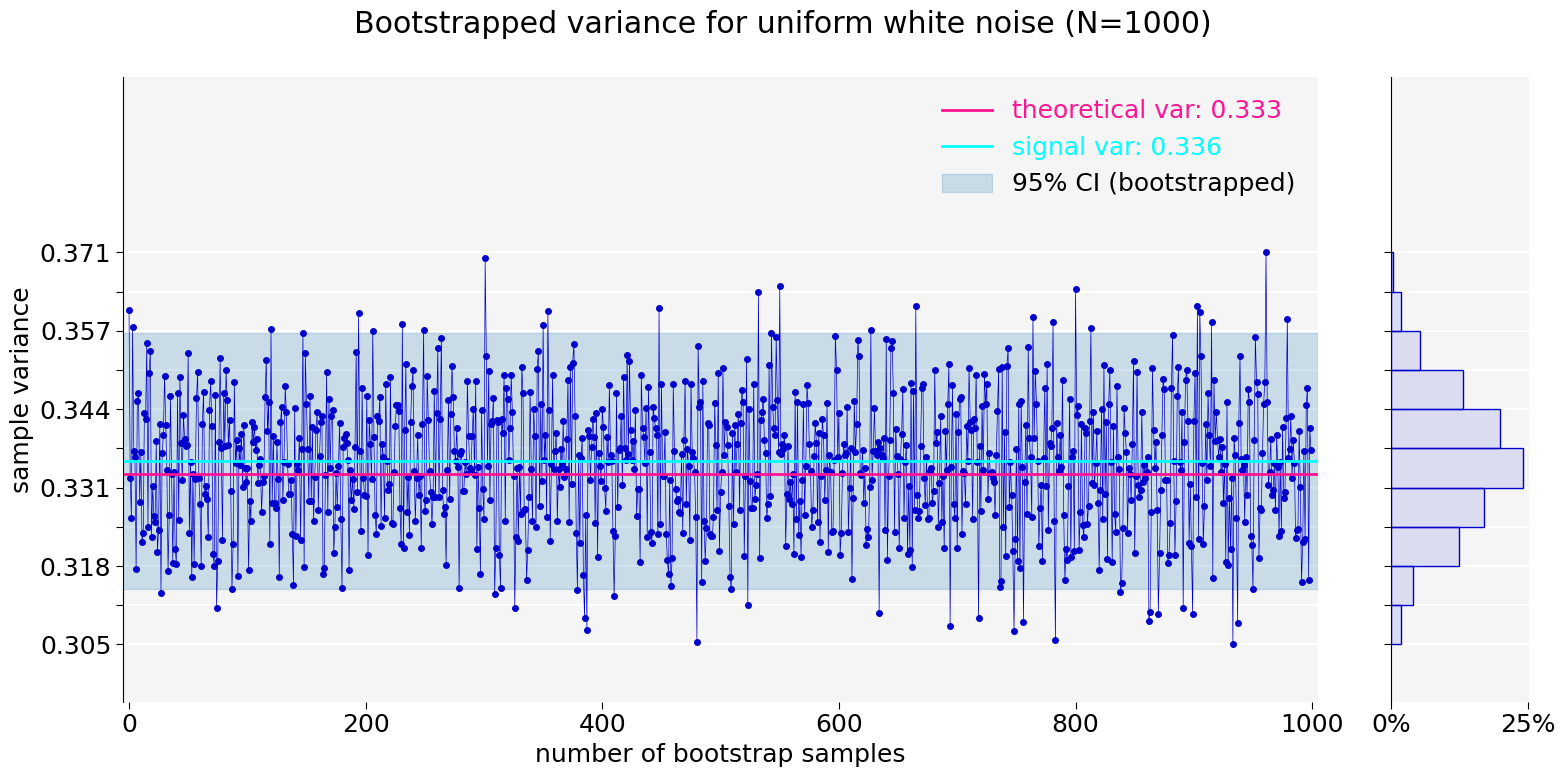

In [15]:
mosaic="aaaaaab"

fig, axs = plt.subplot_mosaic(
    mosaic=mosaic,
    sharey=True,
)

fig.suptitle(f"Bootstrapped variance for uniform white noise (N={nr_of_bootstrap_runs})")

axs["a"].plot(
    bootstrap_variances,
    color=my_blue,
    marker=".",
    markersize=8,
    linewidth=0.5,
)

axs["a"].axhline(
    uni_theoretical_var,
    color="deeppink",
    linewidth=2.0,
    label=f"theoretical var: {uni_theoretical_var:.3f}"
)
axs["a"].axhline(
    signal_var_all,
    color="cyan",
    linewidth=2.0,
    label=f"signal var: {signal_var_all:.3f}"
)

axs["a"].axhspan(
    ymin=ci_var_low,
    ymax=ci_var_high,
    color="#1f77b4",
    alpha=0.2,
    edgecolor=None,
    label="95% CI (bootstrapped)",
)

axs["a"].set_xlim(-5, nr_of_bootstrap_runs+5)
axs["a"].set_ylim(0.295, 0.4)
axs["a"].set_xlabel("number of bootstrap samples")
axs["a"].set_ylabel("sample variance")

n, bins, patches = axs["b"].hist(
    x=bootstrap_variances,
    color=(my_blue, 0.1),
    edgecolor=my_blue,
    orientation="horizontal",
    histtype="bar",
    weights=np.ones_like(bootstrap_variances) / len(bootstrap_variances)
)

axs["b"].set_yticks(bins)
# Plot every 2nd label on Y axis
axs["b"].set_yticklabels([
    f"{value:.3f}" if i % 2 == 0 else " "
    for i, value in enumerate(bins)
])
axs["b"].set_xticks([0, 0.25])
axs["b"].set_xticklabels([f"{value:.0%}" for value in [0, 0.25]])


legend = axs["a"].legend(
    frameon=False,
)
legend.get_texts()[0].set_color("deeppink")
legend.get_texts()[1].set_color("cyan")



#### Constant variance with unknown underlying distribution

In [16]:
# Measure 1: ratio

num_segments=8
threshold=1.5

# Split into non-overlapping segments
segments = np.array_split(white_uniform, num_segments)

# Compute sample variance for each segment
segment_vars = [np.var(s, ddof=1) for s in segments]

# Compute ratio of maximum to minimum segment variance
ratio = np.max(segment_vars) / np.min(segment_vars)

# Compare ratio to threshold
is_stable = ratio < threshold


In [17]:
print(f"Segment Variances: {[round(v, 3) for v in segment_vars]}")
print(f"Max/Min Ratio:     {ratio:.3f}")
print(f"Variance Stable?   {is_stable}")

Segment Variances: [np.float64(0.349), np.float64(0.296), np.float64(0.337), np.float64(0.346), np.float64(0.341), np.float64(0.374), np.float64(0.33), np.float64(0.313)]
Max/Min Ratio:     1.265
Variance Stable?   True


In [18]:
# Measure 2: CV
segment_vars = np.array(segment_vars)
cv = segment_vars.std(ddof=1) / segment_vars.mean()

print(f"CV: {cv:.1%}")

CV: 7.1%


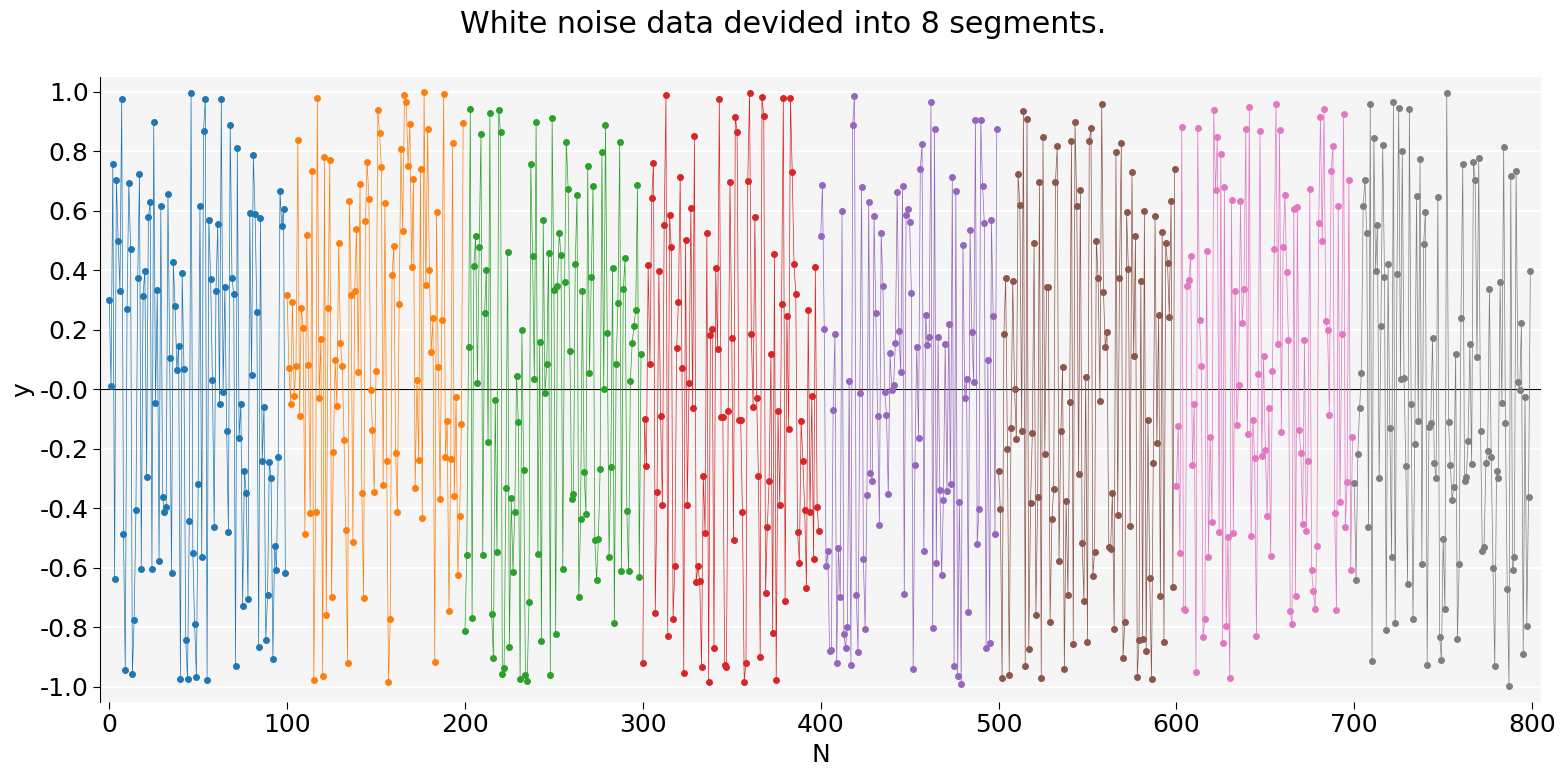

In [19]:
index_array = np.arange(len(white_uniform))
index_segments = np.array_split(index_array, num_segments)

fig, axs = plt.subplots()

fig.suptitle(f"White noise data devided into {num_segments} segments.")

for val_idx, val in zip(index_segments, segments):
    axs.plot(
        val_idx, val,
        # color=my_blue,
        marker=".",
        markersize=8,
        linewidth=0.5,
    )


axs.axhline(
    0,
    color="black",
    linewidth=0.8,
    zorder=1
)

axs.set_xlim(-5, N+5)
axs.set_ylim(-1.05, 1.05)
axs.set_xlabel("N")
axs.set_ylabel("y")
axs.set_yticks(np.arange(-1, 1.2, 0.2))
axs.set_yticklabels([f"{value:.1f}" for value in np.arange(-1, 1.2, 0.2)]);


#### No autocorrelation

In [20]:
# Subtract mean first to center around zero
centered_signal = white_uniform - np.mean(white_uniform)
autocorr = np.correlate(centered_signal, centered_signal, mode='full')

# keep only positive side of autocorrelation
positive_autocorr = autocorr[len(white_uniform)-1:] # keep all data from lag-0, lag-1 etc.
normal_positive_autocorr = positive_autocorr / positive_autocorr[0] # normalize so the spike at lag-0 equals 1

# Threshold
tolerance = 2* (1 / np.sqrt(len(white_uniform)))
hard_cap = 1.5 * tolerance  # Hard threshold for massive spikes

# Identify number of breaches
breaches = np.abs(normal_positive_autocorr[1:]) > tolerance
total_breaches = np.sum(breaches)
breach_pct = total_breaches / len(normal_positive_autocorr[1:])

In [21]:
tolerance

np.float64(0.07071067811865475)

In [22]:
hard_cap

np.float64(0.10606601717798213)

In [23]:
breach_pct


np.float64(0.0050062578222778474)

In [24]:

print(f"Percentage of tolerance breaches: {breach_pct:.1%}")

Percentage of tolerance breaches: 0.5%


Text(0, 0.5, 'raw autocorrelation')

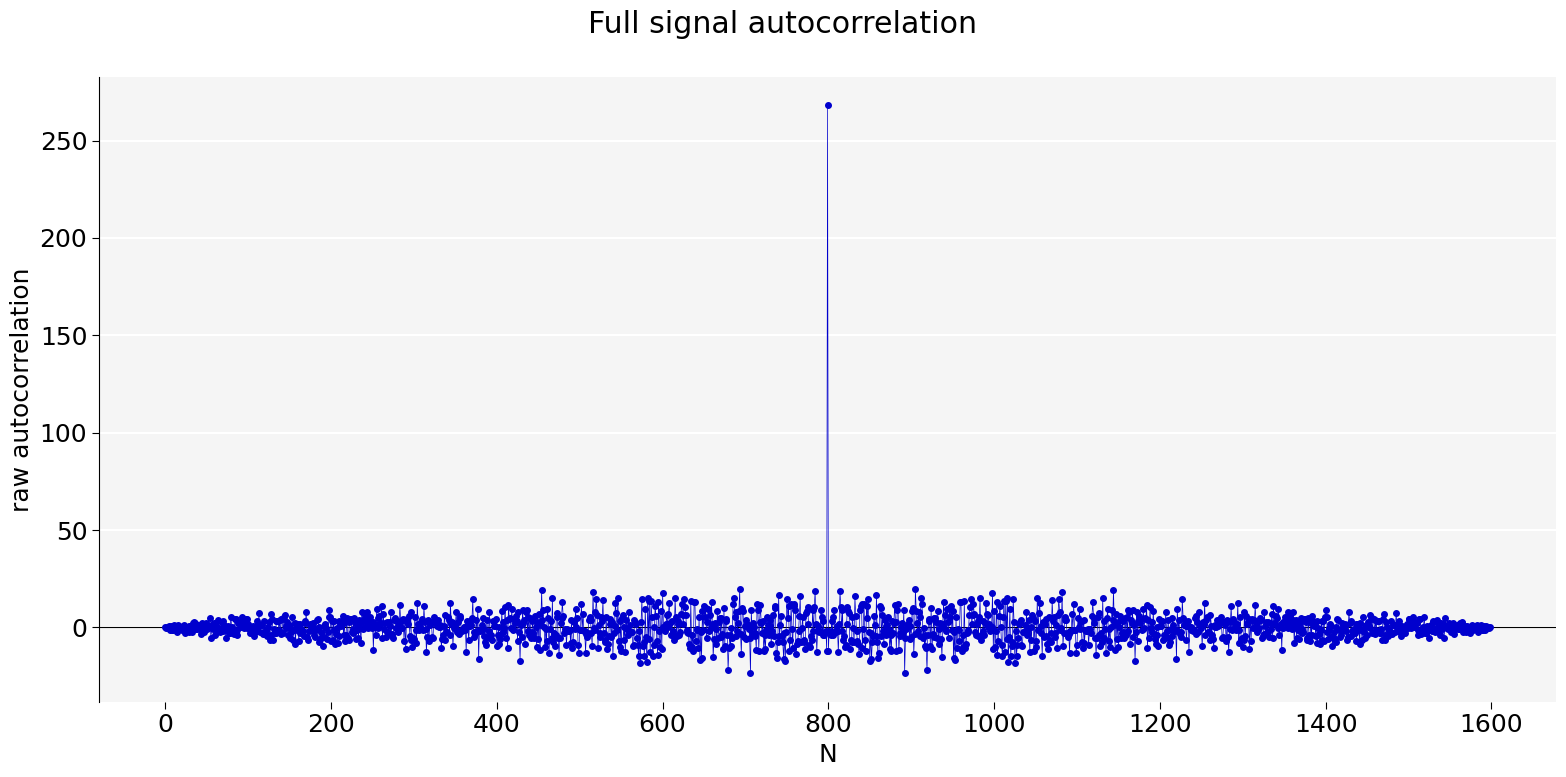

In [25]:
fig, axs = plt.subplots()

fig.suptitle(f"Full signal autocorrelation")

axs.plot(
    autocorr,
    color=my_blue,
    marker=".",
    markersize=8,
    linewidth=0.5,
)


axs.axhline(
    0,
    color="black",
    linewidth=0.8,
    zorder=1
)

# axs.set_xlim(-5, N+5)
# axs.set_ylim(-1.05, 1.05)
axs.set_xlabel("N")
axs.set_ylabel("raw autocorrelation")
# axs.set_yticks(np.arange(-1, 1.2, 0.2))
# axs.set_yticklabels([f"{value:.1f}" for value in np.arange(-1, 1.2, 0.2)]);

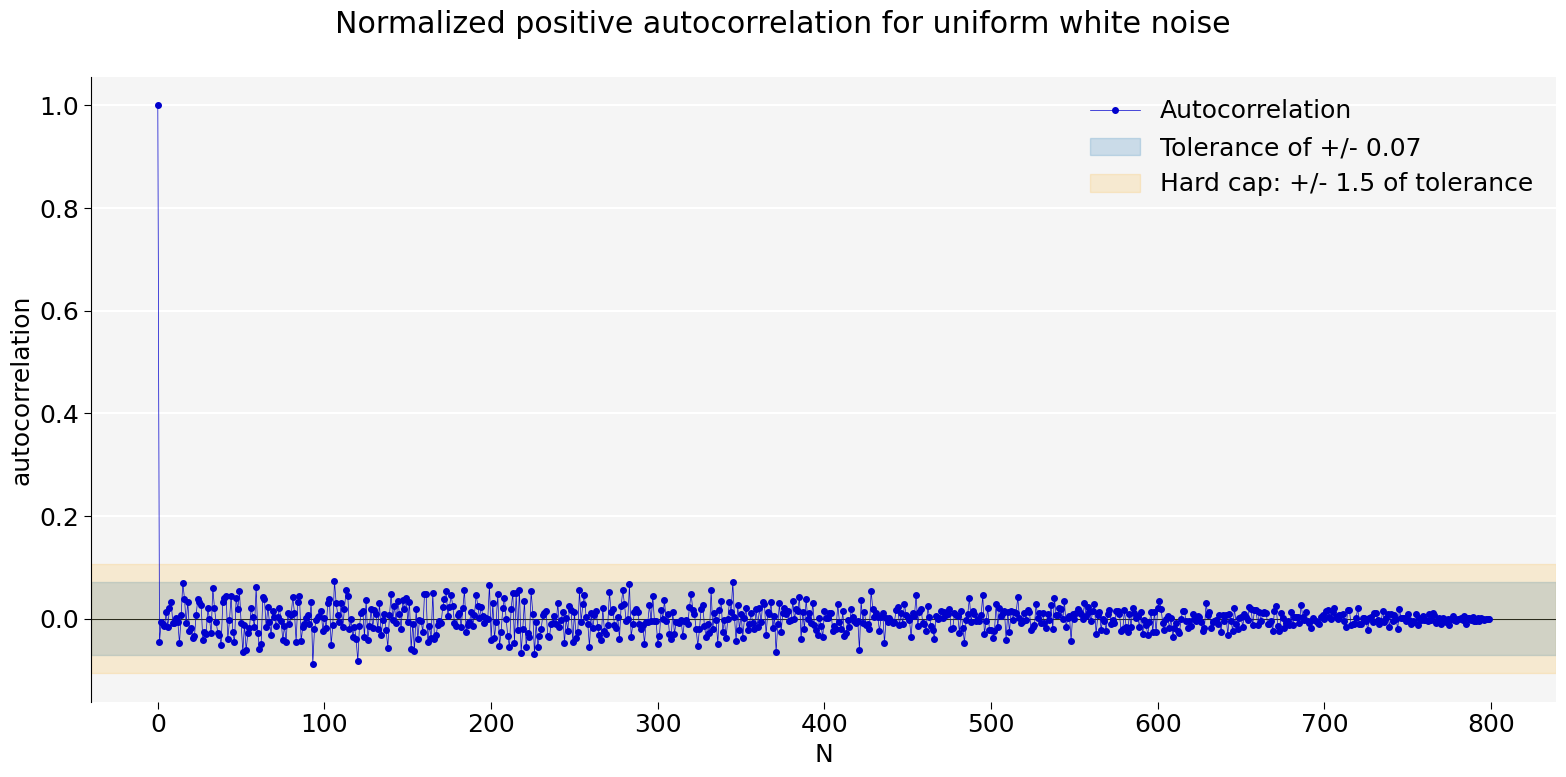

In [26]:
fig, axs = plt.subplots()

fig.suptitle(f"Normalized positive autocorrelation for uniform white noise")

axs.plot(
    normal_positive_autocorr,
    color=my_blue,
    marker=".",
    markersize=8,
    linewidth=0.5,
    label="Autocorrelation"
)

axs.axhline(
    0,
    color="black",
    linewidth=0.8,
    zorder=1
)

axs.axhspan(
    ymin=-tolerance,
    ymax=tolerance,
    color="#1f77b4",
    alpha=0.2,
    edgecolor=None,
    label=f"Tolerance of +/- {tolerance:.2f}",
)
axs.axhspan(
    ymin=-hard_cap,
    ymax=hard_cap,
    color="orange",
    alpha=0.15,
    edgecolor=None,
    label=f"Hard cap: +/- 1.5 of tolerance",
)

# axs.set_xlim(-5, N+5)
# axs.set_ylim(-1.05, 1.05)
axs.set_xlabel("N")
axs.set_ylabel("autocorrelation")
# axs.set_yticks(np.arange(-1, 1.2, 0.2))
# axs.set_yticklabels([f"{value:.1f}" for value in np.arange(-1, 1.2, 0.2)]);

legend = axs.legend(
    frameon=False,
)

## 2D Random walk

In [27]:
N = 800
np.random.seed(19)
x = np.random.uniform(
    low=-1,
    high=1,
    size=N
)
y = np.random.uniform(
    low=-1,
    high=1,
    size=N
)

x_cummulative = np.cumsum(np.insert(x, 0, 0))
y_cummulative = np.cumsum(np.insert(y, 0, 0))

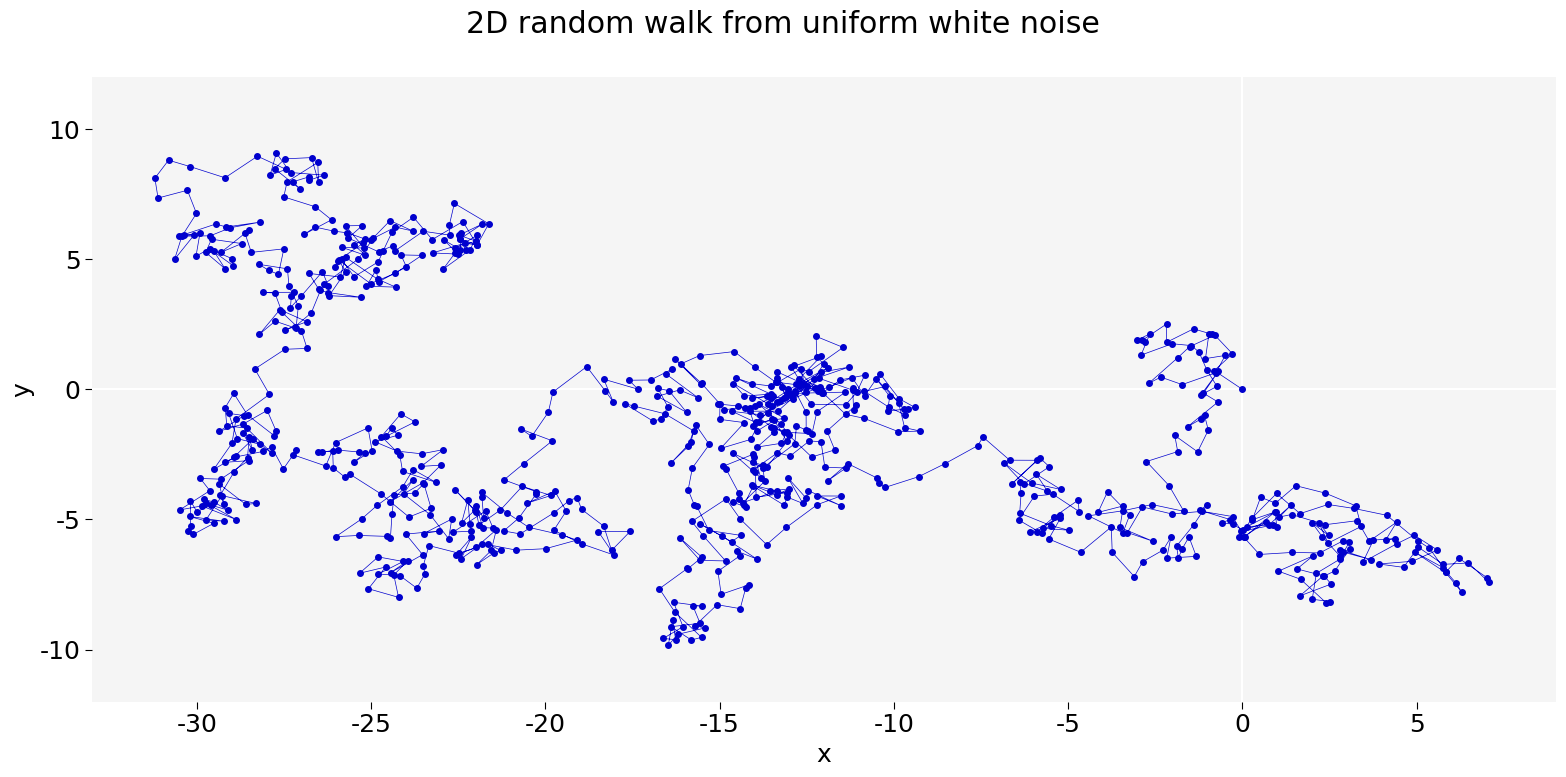

In [28]:
fig, axs = plt.subplots()

fig.suptitle(f"2D random walk from uniform white noise")

axs.plot(
    x_cummulative,
    y_cummulative,
    color=my_blue,
    marker=".",
    markersize=8,
    linewidth=0.5,
)

axs.axhline(
    0,
    color="white",
    linewidth=1.5,
    zorder=1
)
axs.axvline(
    0,
    color="white",
    linewidth=1.5,
    zorder=1
)

axs.set_xlabel("x")
axs.set_ylabel("y")
axs.grid([])


axs.spines["left"].set_visible(False)

axs.set_xlim(-33, 9)
axs.set_ylim(-12, 12)
axs.set_xticks(np.arange(-30, 10, 5))
axs.set_xticklabels([f"{value:d}" for value in np.arange(-30, 10, 5)]);
axs.set_yticks(np.arange(-10, 15, 5))
axs.set_yticklabels([f"{value:d}" for value in np.arange(-10, 15, 5)]);


## Gaussian White Noise

In [29]:
N = 800
np.random.seed(18)
white_gaussian = np.random.normal(
    loc=0,  # mean
    scale=1,  # standard deviation
    size=N
)

In [30]:
white_gaussian

array([ 7.94284438e-02,  2.19020236e+00, -1.34892147e-01,  1.60517982e-01,
        4.42697843e-01,  6.23391441e-01,  1.00890349e+00,  3.94248791e-01,
       -3.36386703e-01, -6.45906463e-01,  8.05457705e-01,  4.16442838e-01,
        5.74619749e-01, -1.10167133e+00, -9.94756872e-01,  1.34551948e+00,
        5.81867813e-01,  5.37238713e-01,  2.06704686e+00, -2.90324116e-01,
        6.01365073e-01, -5.64526820e-01, -1.16795166e+00, -1.02200224e+00,
        8.83519547e-01, -5.33744491e-01, -1.35043218e+00,  2.30094016e-01,
        8.94854834e-01,  1.37075992e+00,  2.46370160e+00,  1.12790137e+00,
       -8.19214149e-01,  6.74641428e-02,  1.07721625e+00, -5.53544962e-01,
        6.77617317e-01,  1.04149369e+00, -1.75142185e+00,  1.18669488e-01,
        1.13870114e+00,  6.77085140e-01,  3.06135174e-01, -1.52722297e-02,
        2.06798861e+00, -4.52681695e-02, -1.60312492e+00, -4.67751770e-01,
        1.48657634e-01,  3.52870846e-01, -2.50650868e-01,  8.61280321e-02,
       -1.70164875e-01,  

In [31]:
signal_var_all = np.var(white_gaussian, ddof=1)
print(f"{signal_var_all:.3f}")

1.088


### Visualize

[Text(0.0, 0, '0%'), Text(0.25, 0, '25%')]

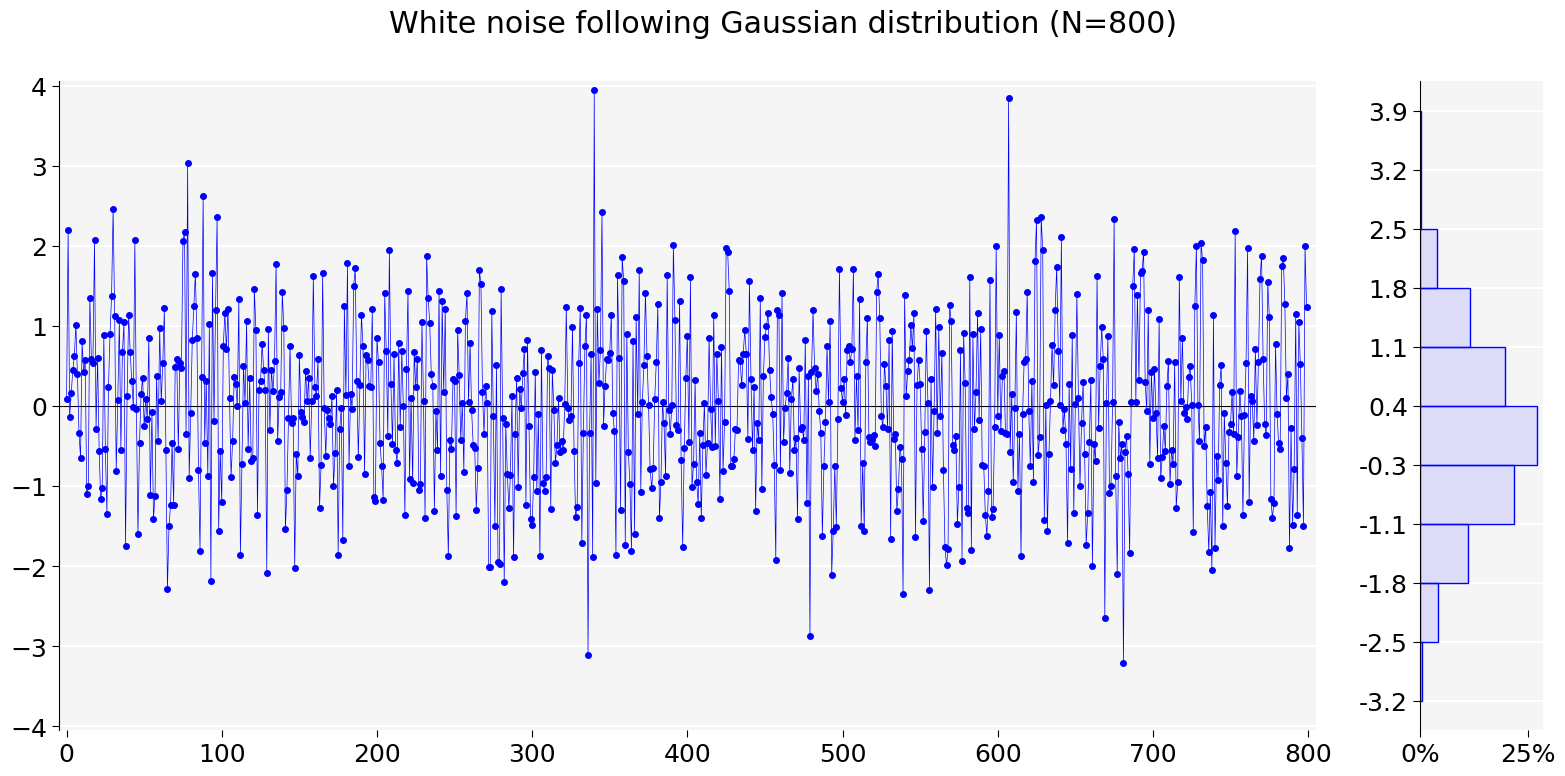

In [32]:
mosaic="aaaaaab"

fig, axs = plt.subplot_mosaic(mosaic=mosaic)

fig.suptitle(f"White noise following Gaussian distribution (N={N})")

axs["a"].plot(
    white_gaussian,
    color="blue",
    marker=".",
    markersize=8,
    linewidth=0.5,
)

axs["a"].axhline(
    0,
    color="black",
    linewidth=0.8,
    zorder=1
)

axs["a"].set_xlim(-5, N+5)
axs["a"].set_ylim(-4.05, 4.05)
axs["a"].set_yticks(range(-4, 5));


n, bins, patches = axs["b"].hist(
    x=white_gaussian,
    color=("blue", 0.1),
    edgecolor="blue",
    orientation="horizontal",
    histtype="bar",
    weights=np.ones_like(white_gaussian) / len(white_gaussian)
)

axs["b"].set_yticks(bins)
axs["b"].set_yticklabels([f"{value:.1f}" for value in bins]);
axs["b"].set_xticks([0, 0.25])
axs["b"].set_xticklabels([f"{value:.0%}" for value in [0, 0.25]])

